# 03 — Random Forest pore classifier

In this notebook, I train a Random Forest classifier to predict pore space in my cropped SEM/BSE images using the Weka masks as reference labels. I use this as a supervised baseline that is more flexible than simple thresholding, but still easier to interpret than a CNN.

My aim here is to test whether a Random Forest using handcrafted pixel-wise image features can predict pore masks and porosity more reliably than Otsu thresholding. I then compare the predicted masks and porosity values against my Weka-derived masks and `porosity_weka` values.

**Workflow:** load inventory → prepare image-level train/validation/test splits → extract handcrafted features → train Random Forest → predict full-image pore masks → calculate segmentation and porosity metrics → save results → preview example outputs.

**Relevant course pages:**
- AI algorithms: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_AI_Algorithms.html
- Full-image rollout: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_rollout_3.html

**Notes**
- I use image-level splits rather than patch-level splits so that pixels from the same image do not leak across training and testing.
- I use the cropped images and corrected Weka masks from my inventory wherever available.
- I expect the Random Forest to perform better than simple thresholding because it can use multiple image features rather than relying on intensity alone.


In [1]:
from pathlib import Path
import os
from google.colab import drive

drive.mount('/content/drive')

REPO_ROOT = Path('/content/drive/MyDrive/GEOL0069-sem-segmentation-project')

if not REPO_ROOT.exists():
    !git clone https://github.com/courtneylorabrown/GEOL0069-sem-segmentation-project "{REPO_ROOT}"

%cd /content/drive/MyDrive/GEOL0069-sem-segmentation-project

DATA_DIR = REPO_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
CROPPED_DIR = DATA_DIR / 'cropped'
MASK_DIR = DATA_DIR / 'masks_weka'
PROB_DIR = DATA_DIR / 'probability_maps'
META_DIR = DATA_DIR / 'metadata'
RESULTS_DIR = REPO_ROOT / 'results'
MODELS_DIR = REPO_ROOT / 'models'
RF_MASK_DIR = RESULTS_DIR / 'rf_masks'
RF_PROB_DIR = RESULTS_DIR / 'rf_probability_maps'

for folder in [RAW_DIR, CROPPED_DIR, MASK_DIR, PROB_DIR, META_DIR, RESULTS_DIR, MODELS_DIR, RF_MASK_DIR, RF_PROB_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

INVENTORY_PATH = META_DIR / 'image_inventory.csv'

print("Inventory:", INVENTORY_PATH)
print("Cropped folder exists:", CROPPED_DIR.exists())
print("Mask folder exists:", MASK_DIR.exists())
print("Results folder exists:", RESULTS_DIR.exists())
print("Models folder exists:", MODELS_DIR.exists())


Mounted at /content/drive
/content/drive/MyDrive/GEOL0069-sem-segmentation-project
Inventory: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/data/metadata/image_inventory.csv
Cropped folder exists: True
Mask folder exists: True
Results folder exists: True
Models folder exists: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import gaussian_filter, uniform_filter
from skimage.filters import sobel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    jaccard_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import joblib

FEATURE_NAMES = [
    "intensity",
    "gaussian_sigma_1",
    "gaussian_sigma_2",
    "sobel_edges",
    "local_mean_5",
    "local_variance_5",
]


def read_gray(path):
    return np.array(Image.open(path).convert("L"))


def read_mask(path):
    arr = np.array(Image.open(path).convert("L"))
    return (arr < 128).astype(np.uint8)


def save_mask(mask, path):
    Image.fromarray((mask * 255).astype(np.uint8)).save(path)


def save_probability_map(prob, path):
    prob_uint8 = np.clip(prob * 255, 0, 255).astype(np.uint8)
    Image.fromarray(prob_uint8).save(path)


def align_mask_to_image(mask, image_shape):
    img_h, img_w = image_shape
    mask = mask[:img_h, :img_w]

    if mask.shape != image_shape:
        padded = np.zeros(image_shape, dtype=mask.dtype)
        padded[:mask.shape[0], :mask.shape[1]] = mask
        mask = padded

    return mask


def porosity_percent(mask):
    return float(mask.mean() * 100.0)


def segmentation_scores(gt, pred):
    return {
        "iou": jaccard_score(gt.ravel(), pred.ravel(), zero_division=0),
        "precision": precision_score(gt.ravel(), pred.ravel(), zero_division=0),
        "recall": recall_score(gt.ravel(), pred.ravel(), zero_division=0),
        "f1": f1_score(gt.ravel(), pred.ravel(), zero_division=0),
    }


def load_inventory(path=INVENTORY_PATH):
    df = pd.read_csv(path)

    for col in ["raw_file", "cropped_file", "weka_mask", "probability_map", "split", "notes"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str)

    if "porosity_weka" in df.columns:
        df["porosity_weka"] = pd.to_numeric(df["porosity_weka"], errors="coerce")

    return df


def assign_default_split(df):
    df = df.copy()

    if "split" not in df.columns:
        df["split"] = ""

    for mag, group in df.groupby("actual_magnification"):
        idx = group.sort_values("image_id").index.tolist()
        labels = []

        if len(idx) >= 1:
            labels.extend(["train"] * min(2, len(idx)))
        if len(idx) >= 3:
            labels.append("val")
        while len(labels) < len(idx):
            labels.append("test")

        for i, label in zip(idx, labels):
            if not str(df.loc[i, "split"]).strip():
                df.loc[i, "split"] = label

    return df


def feature_stack(image):
    image = image.astype(np.float32)

    local_mean = uniform_filter(image, size=5)
    local_sq_mean = uniform_filter(image**2, size=5)
    local_var = np.maximum(local_sq_mean - local_mean**2, 0)

    feats = [
        image,
        gaussian_filter(image, sigma=1),
        gaussian_filter(image, sigma=2),
        sobel(image),
        local_mean,
        local_var,
    ]

    return np.stack(feats, axis=-1)


def sample_balanced_pixels(features, mask, n_per_class=4000, seed=42):
    rng = np.random.default_rng(seed)

    X = features.reshape(-1, features.shape[-1])
    y = mask.reshape(-1)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return None, None

    n_pos = min(len(pos_idx), n_per_class)
    n_neg = min(len(neg_idx), n_per_class)

    pos_sample = rng.choice(pos_idx, size=n_pos, replace=False)
    neg_sample = rng.choice(neg_idx, size=n_neg, replace=False)

    idx = np.concatenate([pos_sample, neg_sample])
    rng.shuffle(idx)

    return X[idx], y[idx]


def predict_full_mask(model, features, threshold=0.5):
    h, w, c = features.shape
    X = features.reshape(-1, c)

    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(np.uint8)

    return prob.reshape(h, w), pred.reshape(h, w)


def show_triplet(image, mask, pred, title=""):
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title(f"{title} image")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Weka mask")
    ax[1].axis("off")

    ax[2].imshow(pred, cmap="gray")
    ax[2].set_title("RF prediction")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


In [3]:
df = assign_default_split(load_inventory())

display(df[[
    "image_id",
    "actual_magnification",
    "cropped_file",
    "weka_mask",
    "porosity_weka",
    "split"
]])

print("Number of rows:", len(df))

split_summary = (
    df.groupby(["actual_magnification", "split"])
      .size()
      .reset_index(name="n_images")
      .sort_values(["actual_magnification", "split"])
)

display(split_summary)


,image_id,actual_magnification,cropped_file,weka_mask,porosity_weka,split
0,13064_05_17A_400X-8-83,400,13064_05_17A_400X-8-83cropped.tif,13064_05_17A_400X-8-83mask.tif,1.000000,train
1,13074_00_18A_400X-9-10,400,13074_00_18A_400X-9-10cropped.tif,13074_00_18A_400X-9-10mask.tif,0.070000,train
2,13123_00_21A_400X-9-59,400,13123_00_21A_400X-9-59cropped.tif,13123_00_21A_400X-9-59mask.tif,2.268000,val
3,R2_10,400,R2_10cropped.tif,R2_10mask.tif,0.000477,test
4,13064_05_17B_1000X-8-83,1000,13064_05_17B_1000X-8-83cropped.tif,13064_05_17B_1000X-8-83mask.tif,1.987000,train
5,13087_50_19B_1000X-9-23,1000,13087_50_19B_1000X-9-23cropped.tif,13087_50_19B_1000X-9-23mask.tif,1.830000,train
6,13103_60_20B_1000X-9-39,1000,13103_60_20B_1000X-9-39cropped.tif,13103_60_20B_1000X-9-39mask.tif,0.445000,val
7,13123_00_21B_1000X-9-59,1000,13123_00_21B_1000X-9-59cropped.tif,13123_00_21B_1000X-9-59mask.tif,1.500000,test
8,13064_05_17C_2000X-8-83,2000,13064_05_17C_2000X-8-83cropped.tif,13064_05_17C_2000X-8-83mask.tif,2.078000,train
9,13087_50_19C_2000X-9-23,2000,13087_50_19C_2000X-9-23cropped.tif,13087_50_19C_2000X-9-23mask.tif,3.567000,train


Number of rows: 16


,actual_magnification,split,n_images
0,400,test,1
1,400,train,2
2,400,val,1
3,1000,test,1
4,1000,train,2
5,1000,val,1
6,2000,test,1
7,2000,train,2
8,2000,val,1
9,3000,test,1


In [4]:
train_X, train_y = [], []
val_images = []
test_images = []

for _, row in df.iterrows():
    image_id = str(row["image_id"]).strip()
    split = str(row["split"]).strip().lower()

    cropped_name = str(row.get("cropped_file", "")).strip()
    raw_name = str(row.get("raw_file", "")).strip()
    mask_name = str(row.get("weka_mask", "")).strip()

    if cropped_name:
        image_path = CROPPED_DIR / cropped_name
    elif raw_name:
        image_path = RAW_DIR / raw_name
    else:
        print(f"Skipping {image_id}: no image file listed.")
        continue

    if not image_path.exists():
        print(f"Skipping {image_id}: image file not found -> {image_path.name}")
        continue

    if not mask_name:
        print(f"Skipping {image_id}: no mask listed.")
        continue

    mask_path = MASK_DIR / mask_name
    if not mask_path.exists():
        print(f"Skipping {image_id}: mask file not found -> {mask_name}")
        continue

    image = read_gray(image_path)
    mask = read_mask(mask_path)
    mask = align_mask_to_image(mask, image.shape)

    feats = feature_stack(image)

    item = {
        "image_id": image_id,
        "image": image,
        "mask": mask,
        "features": feats,
        "porosity_weka": row.get("porosity_weka", np.nan),
        "actual_magnification": row.get("actual_magnification", np.nan),
    }

    if split == "train":
        X, y = sample_balanced_pixels(feats, mask, n_per_class=4000, seed=42)
        if X is not None:
            train_X.append(X)
            train_y.append(y)
    elif split == "val":
        val_images.append(item)
    else:
        test_images.append(item)

X_train = np.vstack(train_X)
y_train = np.concatenate(train_y)

print("Training feature matrix shape:", X_train.shape)
print("Training label vector shape:", y_train.shape)
print("Training pore fraction:", y_train.mean())
print("Number of validation images:", len(val_images))
print("Number of test images:", len(test_images))


Training feature matrix shape: (60636, 6)
Training label vector shape: (60636,)
Training pore fraction: 0.472260703212613
Number of validation images: 4
Number of test images: 4


In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

model_path = MODELS_DIR / "random_forest_pore.pkl"
joblib.dump(rf, model_path)
print("Saved model to:", model_path)

feature_importance_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance_df)

val_rows = []

for item in val_images:
    image_id = item["image_id"]
    image = item["image"]
    mask = item["mask"]
    feats = item["features"]

    prob, pred = predict_full_mask(rf, feats, threshold=0.5)

    pred_mask_path = RF_MASK_DIR / f"{image_id}_rf_mask.png"
    prob_map_path = RF_PROB_DIR / f"{image_id}_rf_probability.png"

    save_mask(pred, pred_mask_path)
    save_probability_map(prob, prob_map_path)

    row = {
        "image_id": image_id,
        "actual_magnification": item["actual_magnification"],
        "weka_porosity": item["porosity_weka"],
        "rf_porosity": porosity_percent(pred),
        "pred_mask_file": pred_mask_path.name,
        "pred_probability_file": prob_map_path.name,
    }
    row.update(segmentation_scores(mask, pred))
    val_rows.append(row)

rf_val_results = pd.DataFrame(val_rows)

if not rf_val_results.empty:
    rf_val_results["abs_error"] = (rf_val_results["rf_porosity"] - rf_val_results["weka_porosity"]).abs()
    display(rf_val_results)
    rf_val_results.to_csv(RESULTS_DIR / "rf_val_results.csv", index=False)
    print("Saved validation results to:", RESULTS_DIR / "rf_val_results.csv")
else:
    print("No validation images were available.")


Saved model to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/models/random_forest_pore.pkl


,feature,importance
2,gaussian_sigma_2,0.333722
4,local_mean_5,0.287679
1,gaussian_sigma_1,0.193217
0,intensity,0.142275
5,local_variance_5,0.034494
3,sobel_edges,0.008613


,image_id,actual_magnification,weka_porosity,rf_porosity,pred_mask_file,pred_probability_file,iou,precision,recall,f1,abs_error
0,13123_00_21A_400X-9-59,400,2.268,2.192514,13123_00_21A_400X-9-59_rf_mask.png,13123_00_21A_400X-9-59_rf_probability.png,0.638099,0.792412,0.766175,0.779073,0.075486
1,13103_60_20B_1000X-9-39,1000,0.445,3.241667,13103_60_20B_1000X-9-39_rf_mask.png,13103_60_20B_1000X-9-39_rf_probability.png,0.137332,0.137342,0.999500,0.241499,2.796667
2,13138_10_22C_2000X-9-74,2000,1.860,2.709230,13138_10_22C_2000X-9-74_rf_mask.png,13138_10_22C_2000X-9-74_rf_probability.png,0.662071,0.671876,0.978434,0.796682,0.849230
3,13150_20_23D_3000X-9-86,3000,3.476,5.336009,13150_20_23D_3000X-9-86_rf_mask.png,13150_20_23D_3000X-9-86_rf_probability.png,0.650371,0.650804,0.998979,0.788151,1.860009


Saved validation results to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/rf_val_results.csv


,image_id,actual_magnification,weka_porosity,rf_porosity,pred_mask_file,pred_probability_file,iou,precision,recall,f1,abs_error
0,R2_10,400,0.000477,0.000000,R2_10_rf_mask.png,R2_10_rf_probability.png,0.000000,0.000000,0.000000,0.000000,0.000477
1,13123_00_21B_1000X-9-59,1000,1.500000,3.734338,13123_00_21B_1000X-9-59_rf_mask.png,13123_00_21B_1000X-9-59_rf_probability.png,0.398048,0.399102,0.993410,0.569434,2.234338
2,B3_2,2000,0.913000,0.000757,B3_2_rf_mask.png,B3_2_rf_probability.png,0.000829,1.000000,0.000829,0.001658,0.912243
3,13162_65_24D_3000X-10-8,3000,3.408000,5.893351,13162_65_24D_3000X-10-8_rf_mask.png,13162_65_24D_3000X-10-8_rf_probability.png,0.480947,0.512549,0.886370,0.649513,2.485351


Saved test results to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/rf_test_results.csv
Saved summary to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/rf_summary_by_magnification.csv


,actual_magnification,n_images,mean_weka_porosity,mean_rf_porosity,mean_abs_error,mean_iou,mean_f1
0,400,1,0.000477,0.000000,0.000477,0.000000,0.000000
1,1000,1,1.500000,3.734338,2.234338,0.398048,0.569434
2,2000,1,0.913000,0.000757,0.912243,0.000829,0.001658
3,3000,1,3.408000,5.893351,2.485351,0.480947,0.649513


              precision    recall  f1-score   support

           0      0.997     0.988     0.992   3847051
           1      0.468     0.754     0.578     53685

    accuracy                          0.985   3900736
   macro avg      0.733     0.871     0.785   3900736
weighted avg      0.989     0.985     0.987   3900736



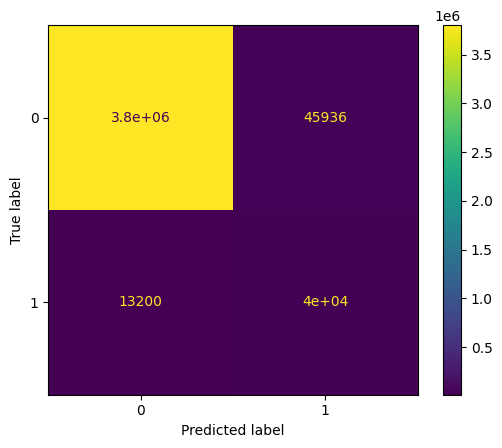

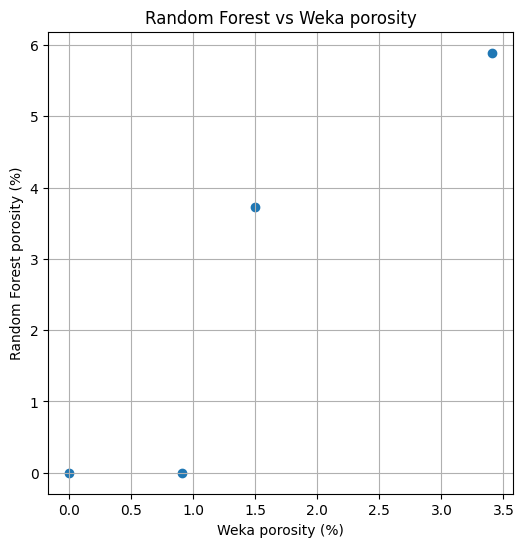

In [6]:
test_rows = []
y_true_all = []
y_pred_all = []

for item in test_images:
    image_id = item["image_id"]
    image = item["image"]
    mask = item["mask"]
    feats = item["features"]

    prob, pred = predict_full_mask(rf, feats, threshold=0.5)

    pred_mask_path = RF_MASK_DIR / f"{image_id}_rf_mask.png"
    prob_map_path = RF_PROB_DIR / f"{image_id}_rf_probability.png"

    save_mask(pred, pred_mask_path)
    save_probability_map(prob, prob_map_path)

    y_true_all.append(mask.ravel())
    y_pred_all.append(pred.ravel())

    row = {
        "image_id": image_id,
        "actual_magnification": item["actual_magnification"],
        "weka_porosity": item["porosity_weka"],
        "rf_porosity": porosity_percent(pred),
        "pred_mask_file": pred_mask_path.name,
        "pred_probability_file": prob_map_path.name,
    }
    row.update(segmentation_scores(mask, pred))
    test_rows.append(row)

rf_test_results = pd.DataFrame(test_rows)

if not rf_test_results.empty:
    rf_test_results["abs_error"] = (rf_test_results["rf_porosity"] - rf_test_results["weka_porosity"]).abs()
    display(rf_test_results)

    test_csv = RESULTS_DIR / "rf_test_results.csv"
    rf_test_results.to_csv(test_csv, index=False)
    print("Saved test results to:", test_csv)

    summary = (
        rf_test_results
        .groupby("actual_magnification", dropna=False)
        .agg(
            n_images=("image_id", "count"),
            mean_weka_porosity=("weka_porosity", "mean"),
            mean_rf_porosity=("rf_porosity", "mean"),
            mean_abs_error=("abs_error", "mean"),
            mean_iou=("iou", "mean"),
            mean_f1=("f1", "mean"),
        )
        .reset_index()
    )

    summary_csv = RESULTS_DIR / "rf_summary_by_magnification.csv"
    summary.to_csv(summary_csv, index=False)

    print("Saved summary to:", summary_csv)
    display(summary)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    print(classification_report(y_true, y_pred, digits=3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(rf_test_results["weka_porosity"], rf_test_results["rf_porosity"])
    plt.xlabel("Weka porosity (%)")
    plt.ylabel("Random Forest porosity (%)")
    plt.title("Random Forest vs Weka porosity")
    plt.grid(True)
    plt.show()
else:
    print("No test images were available.")


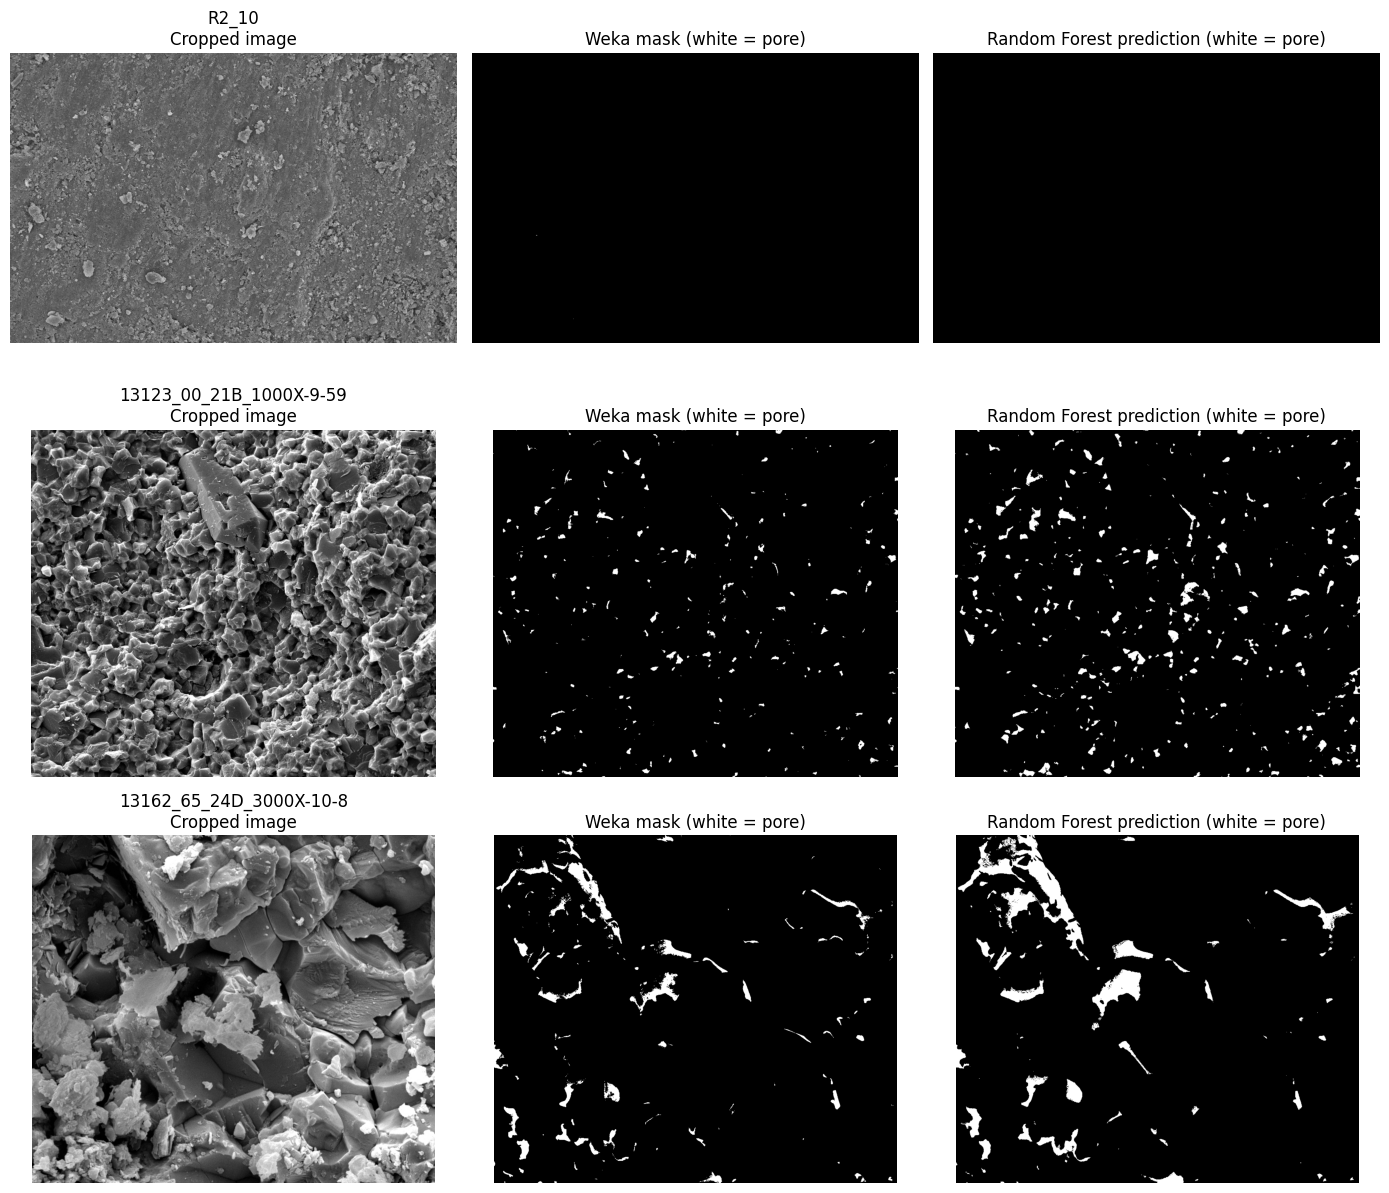

Selected images:
- R2_10
- 13123_00_21B_1000X-9-59
- 13162_65_24D_3000X-10-8


,image_id,actual_magnification,weka_porosity,rf_porosity,iou,precision,recall,f1,abs_error
0,R2_10,400,0.000477,0.000000,0.000000,0.000000,0.00000,0.000000,0.000477
1,13123_00_21B_1000X-9-59,1000,1.500000,3.734338,0.398048,0.399102,0.99341,0.569434,2.234338
2,13162_65_24D_3000X-10-8,3000,3.408000,5.893351,0.480947,0.512549,0.88637,0.649513,2.485351


In [9]:
# Show 3 test examples: low, middle, and high porosity
if len(test_images) > 0 and not rf_test_results.empty:
    view_df = rf_test_results.copy()
    view_df["weka_porosity"] = pd.to_numeric(view_df["weka_porosity"], errors="coerce")
    view_df = view_df.dropna(subset=["weka_porosity"]).sort_values("weka_porosity").reset_index(drop=True)

    if len(view_df) >= 3:
        sample_ids = [
            view_df.iloc[0]["image_id"],                 # lowest porosity
            view_df.iloc[len(view_df) // 2]["image_id"], # middle porosity
            view_df.iloc[-1]["image_id"],                # highest porosity
        ]
    else:
        sample_ids = view_df["image_id"].tolist()

    fig, axes = plt.subplots(len(sample_ids), 3, figsize=(14, 4 * len(sample_ids)))

    if len(sample_ids) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, sample_id in enumerate(sample_ids):
        sample_item = next(item for item in test_images if item["image_id"] == sample_id)
        result_row = rf_test_results[rf_test_results["image_id"] == sample_id].iloc[0]

        image = sample_item["image"]
        mask = sample_item["mask"]
        feats = sample_item["features"]

        prob, pred = predict_full_mask(rf, feats, threshold=0.5)

        axes[r, 0].imshow(image, cmap="gray")
        axes[r, 0].set_title(f"{sample_id}\nCropped image")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(mask, cmap="gray")
        axes[r, 1].set_title("Weka mask (white = pore)")
        axes[r, 1].axis("off")

        axes[r, 2].imshow(pred, cmap="gray")
        axes[r, 2].set_title("Random Forest prediction (white = pore)")
        axes[r, 2].axis("off")

    plt.tight_layout()
    plt.show()

    print("Selected images:")
    for sample_id in sample_ids:
        print("-", sample_id)

    display(
        rf_test_results.loc[
            rf_test_results["image_id"].isin(sample_ids),
            ["image_id", "actual_magnification", "weka_porosity", "rf_porosity", "iou", "precision", "recall", "f1", "abs_error"]
        ].sort_values("weka_porosity").reset_index(drop=True)
    )

else:
    print("No test examples available to preview.")


## Conclusion

In this notebook, I trained a Random Forest classifier to predict pore space from my cropped SEM/BSE images using the Weka masks as reference labels. Compared with the Otsu baseline, the Random Forest produced more realistic pore masks and better overlap with the reference masks, showing that a supervised feature-based method is more suitable for this dataset than simple intensity thresholding.

However, the results still varied across the test images. The model performed better on images with clearer or higher visible porosity, but it was weaker on very sparse pore cases and sometimes overpredicted pore space. Overall, this makes the Random Forest a useful and more reliable baseline than Otsu, while still showing that performance remains variable across the dataset. This provides a strong basis for comparison with the CNN-based approach, which did not clearly outperform the Random Forest on this small dataset.



